In [1]:
import numpy as np 
import pandas as pd 
import os
import numpy as np
import pandas as pd
from pathlib import Path
import os.path
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img,img_to_array
print(tf.__version__)

2.10.0


In [2]:
physical_devices = tf.config.experimental.list_physical_devices('GPU')
print("Num GPUs Available: ", len(physical_devices))
tf.config.experimental.set_memory_growth(physical_devices[0], True)

Num GPUs Available:  1


In [3]:
# Create a list with the filepaths for training and testing
train_dir = Path(r'C:/Users/Rafin/OneDrive/Desktop/NSU/NSU 10th Semester/CSE299/PROJECT/Datasets/Bangla_Food58_V2/train')
train_filepaths = list(train_dir.glob(r'**/*.jpg'))

test_dir = Path(r'C:/Users/Rafin/OneDrive/Desktop/NSU/NSU 10th Semester/CSE299/PROJECT/Datasets/Bangla_Food58_V2/test')
test_filepaths = list(test_dir.glob(r'**/*.jpg'))

val_dir = Path(r'C:/Users/Rafin/OneDrive/Desktop/NSU/NSU 10th Semester/CSE299/PROJECT/Datasets/Bangla_Food58_V2/valid')
val_filepaths = list(val_dir.glob(r'**/*.jpg'))

In [4]:
def image_processing(filepath):
    labels = [str(filepath[i]).split("\\")[-2] \
        for i in range(len(filepath))]
    filepath = pd.Series(filepath, name='Filepath').astype(str)
    labels = pd.Series(labels, name='Label')
    df = pd.concat([filepath, labels], axis=1)
    df = df.sample(frac=1).reset_index(drop = True)
    return df

In [5]:
train_df = image_processing(train_filepaths)
test_df = image_processing(test_filepaths)
val_df = image_processing(val_filepaths)

In [6]:
print('-- Training set --\n')
print(f'Number of pictures: {train_df.shape[0]}\n')
print(f'Number of different labels: {len(train_df.Label.unique())}\n')
print(f'Labels: {train_df.Label.unique()}')

-- Training set --

Number of pictures: 23905

Number of different labels: 58

Labels: ['pizza' 'Momo' 'Begun Bhaja' 'Hilsha_Fish_Curry' 'Burger'
 'Chocolate_cake' 'Fried fish_Mach Bhaja' 'French_fries' 'Sondesh'
 'Chicken_curry' 'Singgara' 'Chitoi  Pitha' 'omelette' 'Fried_rice'
 'Shik_kabab' 'cheesecake' 'Alu Bhorta' 'Fried chicken - Murg Bhaja' 'Doi'
 'Prawn curry - Chingri bhuna' 'Chicken_wings' 'Jorda'
 'kebab - Gosht Kebab' 'Kacchi' 'Shawarma' 'Salad' 'Noodles'
 'Lentil soup_Dal' 'Alu-Vaji' 'Korola-Vaji' 'Cake' 'Sandwich' 'Shak-Vaji'
 'ice_cream' 'Lentil fritters - Dal Puri' 'Biriyani' 'poached_egg'
 'Tundul ruti - Nan Ruti' 'Vegetable fritters - Beguni' 'Fuchka' 'Rice'
 'Jalebi' 'Misti' 'Chicken_Grill' 'Boiled_egg' 'Khichuri' 'Payesh-Firni'
 'Shemai' 'Parata' 'Fish Bhuna_Mach Bhuna' 'Rosogolla' 'Begun Bhorta'
 'Meat Curry_Gosht Bhuna' 'Mixed vegetable stir-fry - Torkari' 'Falooda'
 'Borhani' 'Vapa Pitha' 'Lal-shak-Vaji']


In [7]:
train_df.head(58)

,Filepath,Label
0,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,pizza
1,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,Momo
2,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,Momo
3,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,Momo
4,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,Begun Bhaja
5,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,Hilsha_Fish_Curry
6,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,Burger
7,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,Chocolate_cake
8,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,Chocolate_cake
9,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,Fried fish_Mach Bhaja


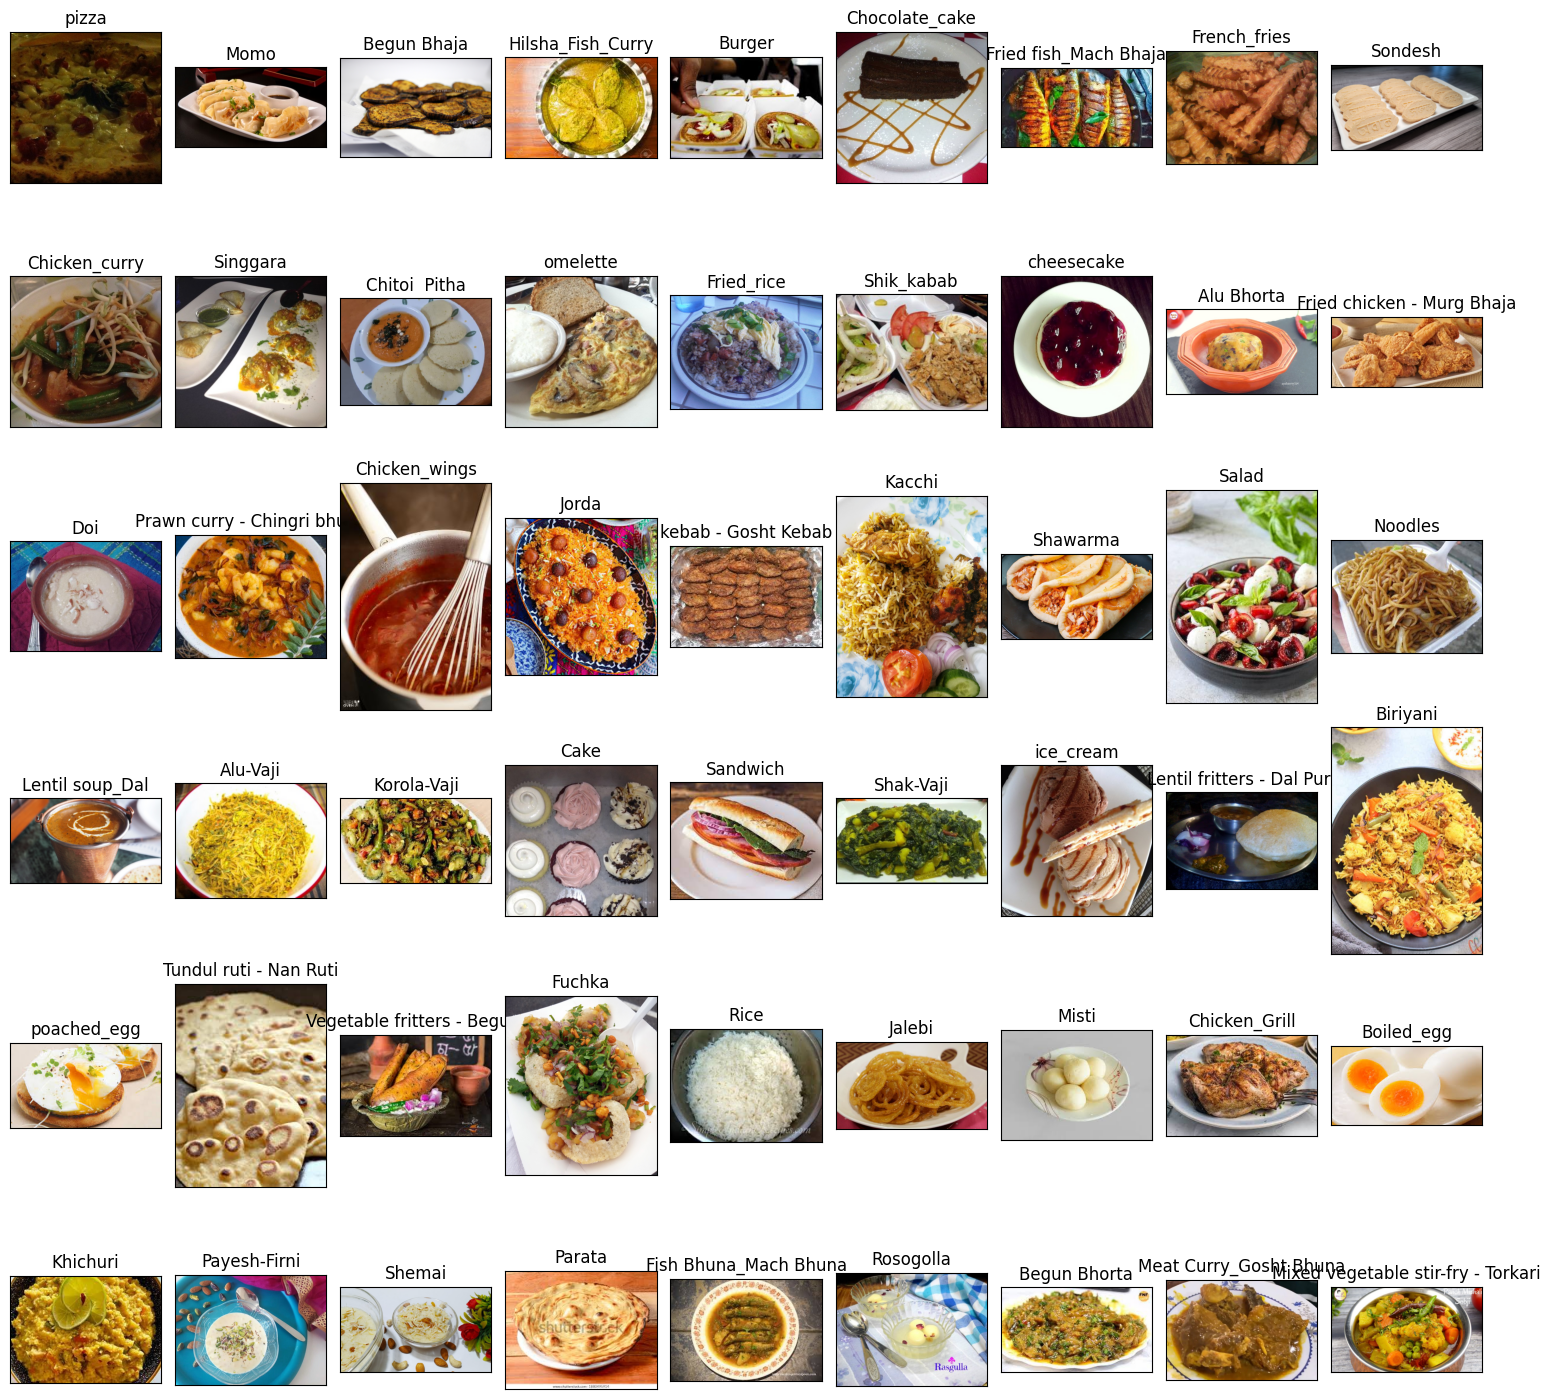

In [8]:
# Create a DataFrame with one Label of each category
df_unique = train_df.copy().drop_duplicates(subset=["Label"]).reset_index()

# Display some pictures of the dataset
fig, axes = plt.subplots(nrows=6, ncols=9,figsize=(15, 15),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(df_unique.Filepath[i]))
    ax.set_title(df_unique.Label[i], fontsize = 12)
plt.tight_layout(pad=1)
plt.show()

In [9]:
train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

test_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

In [10]:
train_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=0,
    rotation_range=30,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

Found 23905 validated image filenames belonging to 58 classes.


In [11]:
val_images = train_generator.flow_from_dataframe(
    dataframe=val_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=0,
    rotation_range=30,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

Found 1743 validated image filenames belonging to 58 classes.


In [12]:
test_images = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

Found 286 validated image filenames belonging to 58 classes.


In [13]:
pretrained_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)
pretrained_model.trainable = False

In [14]:
inputs = pretrained_model.input

x = tf.keras.layers.Dense(128, activation='relu')(pretrained_model.output)
x = tf.keras.layers.Dense(128, activation='relu')(x)

outputs = tf.keras.layers.Dense(58, activation='softmax')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_images,
    validation_data=val_images,
    batch_size = 32,
    epochs=15,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True
        )
    ]
)

Epoch 1/15
748/748 [==============================] - 233s 301ms/step - loss: 1.3501 - accuracy: 0.6369 - val_loss: 1.5007 - val_accuracy: 0.5921
Epoch 2/15
748/748 [==============================] - 103s 138ms/step - loss: 0.7870 - accuracy: 0.7661 - val_loss: 1.3421 - val_accuracy: 0.6403
Epoch 3/15
748/748 [==============================] - 104s 139ms/step - loss: 0.6244 - accuracy: 0.8128 - val_loss: 1.3599 - val_accuracy: 0.6523
Epoch 4/15
748/748 [==============================] - 102s 137ms/step - loss: 0.4888 - accuracy: 0.8491 - val_loss: 1.3924 - val_accuracy: 0.6604
Epoch 5/15
748/748 [==============================] - 102s 136ms/step - loss: 0.3911 - accuracy: 0.8773 - val_loss: 1.4093 - val_accuracy: 0.6667
Epoch 6/15
748/748 [==============================] - 103s 137ms/step - loss: 0.3128 - accuracy: 0.9026 - val_loss: 1.4130 - val_accuracy: 0.6810
Epoch 7/15
748/748 [==============================] - 102s 136ms/step - loss: 0.2406 - accuracy: 0.9242 - val_loss: 1.6110 -

In [15]:
pretrained_model.trainable = True

# Let's take a look to see how many layers are in the base model
print("Number of layers in the base model: ", len(pretrained_model.layers))

# Fine-tune from this layer onwards
fine_tune_at = 100

# Freeze all the layers before the `fine_tune_at` layer
for layer in pretrained_model.layers[:fine_tune_at]:
  layer.trainable =  False

Number of layers in the base model:  155


In [16]:
history = model.fit(
    train_images,
    validation_data=val_images,
    batch_size = 32,
    epochs=15,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True
        )
    ]
)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Epoch 1/15
748/748 [==============================] - 103s 137ms/step - loss: 0.0856 - accuracy: 0.9702 - val_loss: 2.3702 - val_accuracy: 0.6627
Epoch 2/15
748/748 [==============================] - 100s 133ms/step - loss: 0.0714 - accuracy: 0.9765 - val_loss: 2.5388 - val_accuracy: 0.6718
Epoch 3/15
748/748 [==============================] - 99s 133ms/step - loss: 0.0687 - accuracy: 0.9764 - val_loss: 2.7823 - val_accuracy: 0.6781
Epoch 4/15
748/748 [==============================] - 104s 139ms/step - loss: 0.0726 - accuracy: 0.9746 - val_loss: 2.8404 - val_accuracy: 0.6713
Epoch 5/15
748/748 [==============================] - 105s 140ms/step - loss: 0.0726 - accuracy: 0.9761 - val_loss: 3.0288 - val_accuracy: 0.6649
Epoch 6/15
748/748 [==============================] - 106s 141ms/step - loss: 0.0730 - accuracy: 0.9760 - val_loss: 2.7657 - val_accuracy: 0.6724
Epoch 7/15
748/748 [==============================] - 102s 136ms/step - loss: 0.0568 - accuracy: 0.9812 - val_loss: 3.0609 - 

In [17]:
# Predict the label of the test_images
pred = model.predict(test_images)
pred = np.argmax(pred,axis=1)
# Map the label
labels = (train_images.class_indices)
labels = dict((v,k) for k,v in labels.items())
pred1 = [labels[k] for k in pred]
pred1

9/9 [==============================] - 3s 293ms/step


['Misti',
 'Kacchi',
 'Biriyani',
 'Momo',
 'Payesh-Firni',
 'Fish Bhuna_Mach Bhuna',
 'Noodles',
 'Vapa Pitha',
 'Sandwich',
 'Chicken_wings',
 'Hilsha_Fish_Curry',
 'Lal-shak-Vaji',
 'Kacchi',
 'omelette',
 'Korola-Vaji',
 'Fried fish_Mach Bhaja',
 'Kacchi',
 'cheesecake',
 'Chicken_curry',
 'Fish Bhuna_Mach Bhuna',
 'Begun Bhorta',
 'Payesh-Firni',
 'Singgara',
 'ice_cream',
 'Fuchka',
 'Momo',
 'ice_cream',
 'Burger',
 'Doi',
 'omelette',
 'Chocolate_cake',
 'Parata',
 'Biriyani',
 'Jalebi',
 'Biriyani',
 'pizza',
 'cheesecake',
 'Fried fish_Mach Bhaja',
 'Fried fish_Mach Bhaja',
 'Momo',
 'Chitoi  Pitha',
 'cheesecake',
 'Lentil soup_Dal',
 'Burger',
 'Sondesh',
 'Fried fish_Mach Bhaja',
 'Shak-Vaji',
 'Cake',
 'Korola-Vaji',
 'ice_cream',
 'Chicken_curry',
 'Biriyani',
 'Lentil fritters - Dal Puri',
 'Fuchka',
 'pizza',
 'Chitoi  Pitha',
 'Shawarma',
 'Burger',
 'Fried chicken - Murg Bhaja',
 'Rice',
 'pizza',
 'Doi',
 'Begun Bhaja',
 'Chocolate_cake',
 'Burger',
 'Fried chicken 

In [18]:
def output(location):
    img=load_img(location,target_size=(224,224,3))
    img=img_to_array(img)
    img=img/255
    img=np.expand_dims(img,[0])
    answer=model.predict(img)
    y_class = answer.argmax(axis=-1)
    y = " ".join(str(x) for x in y_class)
    y = int(y)
    res = labels[y]
    return res

In [35]:
img = output(r'C:/Users/Rafin/OneDrive/Desktop/NSU/NSU 10th Semester/CSE299/PROJECT/CSE299.1_CalorieMate/MobileNet_Test_Images/b.jpg')
img

1/1 [==============================] - 0s 24ms/step


'Jalebi'

In [ ]:
model.save('Food_FineTuned_V3.h5')